# Home Exercise on Linear Regression - Part 2
## Task Description
Implement a **logistic regression model** using *gradient descent, Adam, any other optimization method* to optimize the parameters or closed-form solution. (You can use other variations of Linear Regression, such as **Lasso, Ridge, etc**, but you must implement them yourself.)

 
* You are only allowed to use computational libraries such as NumPy, Math, etc for implementing the model and training process.
  
* You must not use machine learning libraries or frameworks like scikit-learn, TensorFlow, PyTorch, etc. that provide pre-built models.

* For other tasks (e.g., data processing, visualization), you are free to use any library.

After implementing the model, use it to solve the following problem: [Titanic - Machine Learning from Disaster](https://www.kaggle.com/competitions/titanic/)

## Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, shutil

import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

## Download and load dataset into DataFrame

In [2]:
def moving_folder(path, des):
    if not os.path.exists(path) or not os.path.exists(des):
        print(f"Error: Source folder '{path}' not found.")
        return
    try:
        shutil.move(path, des)
        print(f"Successfully moved folder '{os.path.basename(path)}' to '{des}'")
    except shutil.Error as e:
        print(f"There are errors. Try again!")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

# moving_folder("titanic.zip", "./data")

In [ ]:
!kaggle comp etitions download -c titanic

Traceback (most recent call last):
  File "/home/dikhang/miniconda3/envs/llms/bin/kaggle", line 3, in <module>
    from kaggle.cli import main
  File "/home/dikhang/miniconda3/envs/llms/lib/python3.11/site-packages/kaggle/__init__.py", line 6, in <module>
    api.authenticate()
  File "/home/dikhang/miniconda3/envs/llms/lib/python3.11/site-packages/kaggle/api/kaggle_api_extended.py", line 434, in authenticate
    raise IOError('Could not find {}. Make sure it\'s located in'
OSError: Could not find kaggle.json. Make sure it's located in /home/dikhang/.config/kaggle. Or use the environment method. See setup instructions at https://github.com/Kaggle/kaggle-api/


In [3]:
import zipfile
def unzip_file(path, des, delete=True):
    if not os.path.exists(path) or not os.path.exists(des):
        print(f"Error: Source folder '{path}' not found.")
        return
    with zipfile.ZipFile(path) as zipref:
        zipref.extractall(des)
        print(f"Extracted zipfile in {des}")
    if delete:
        os.remove(path)
        return

In [12]:
data_dir = "./data"
zip_path = os.path.join(data_dir, "titanic.zip")

# unzip_file(zip_path, data_dir, True)

train_path = os.path.join(data_dir, "train.csv")
test_path = os.path.join(data_dir, "test.csv")

if os.path.exists(train_path) and os.path.exists(test_path):
    df_train = pd.read_csv(train_path)
    df_test = pd.read_csv(test_path)
    
    print(f"Load dataset in to train and test DataFrame successfully. Train_df info is:\n{df_train.info()}")

else:
    print("There are errors.")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
Load dataset in to train and test DataFrame successfully. Train_df info is:
None


## Data preprocessing

### Checking raw dataset

In [5]:
print(f"Dataset shape: {df_train.shape}")
df_train.info()
df_train.describe(include='all')

Dataset shape: (891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,1601,NaN,B96 B98,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [15]:
print(df_test.info())
print("==" * 20)
print(df_test.keys)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB
None
<bound method NDFrame.keys of      PassengerId  Pclass                                          Name  \
0            892       3                              Kelly, Mr. James   
1            893       3              Wilkes, Mrs. James (Ellen Needs)   
2            894       2     


Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Survival rate:
Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

Statistical summary:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

   

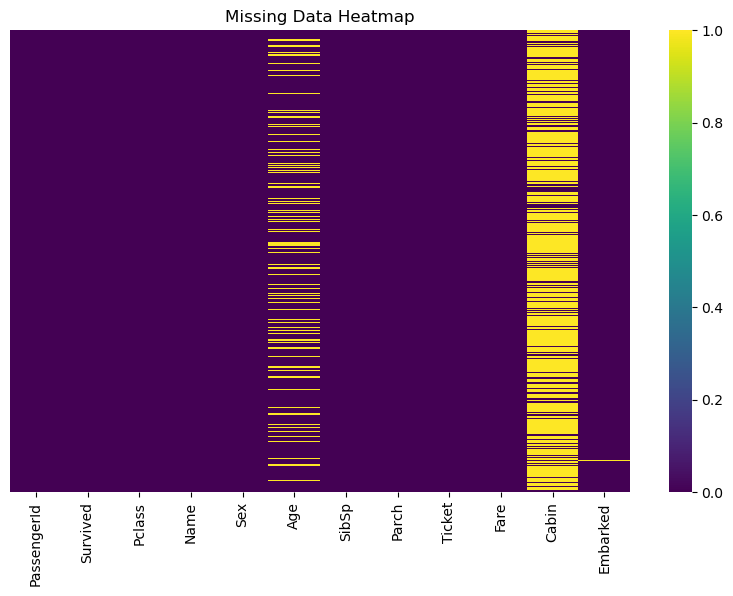

In [6]:
print("\nMissing values:")
print(df_train.isnull().sum())

print("\nSurvival rate:")
print(df_train['Survived'].value_counts(normalize=True))

print("\nStatistical summary:")
print(df_train.describe())

# Visualize missing data
plt.figure(figsize=(10, 6))
sns.heatmap(df_train.isnull(), yticklabels=False, cbar=True, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.show()

### Preprocessing data

This is work-flow of this section:

1. Import libraries and dataset
2. Data exploration
3. Split features and labels
4. Split training, validation and test sets
5. Handle missing values
6. Clean up data (drop unuseful columns)
7. Encode categorical features
8. Feature scaling

In [19]:
# Features and labels split
X = df_train.drop('Survived', axis=1)
y = df_train['Survived']

X_test = df_test

# Split training, validation and test sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print("Test set shape: ", X_test.shape)

Training set shape: (712, 11)
Validation set shape: (179, 11)
Test set shape:  (418, 11)


In [20]:
from sklearn.impute import SimpleImputer
# Handle missing value
def handle_missing_values(X_train, X_val, X_test):
    """Handle missing values for all sets consistently"""
    
    # Make copies to avoid modifying original data
    X_train_processed = X_train.copy()
    X_val_processed = X_val.copy()
    X_test_processed = X_test.copy()
    
    # --- Handle Age: median imputation ---
    age_imputer = SimpleImputer(strategy="median")
    X_train_processed["Age"] = age_imputer.fit_transform(X_train_processed[["Age"]]).ravel()
    X_val_processed["Age"]   = age_imputer.transform(X_val_processed[["Age"]]).ravel()
    X_test_processed["Age"]  = age_imputer.transform(X_test_processed[["Age"]]).ravel()
    
    # --- Handle Embarked: fill with mode from training set ---
    embarked_mode = (
        X_train_processed["Embarked"].mode()[0] 
        if not X_train_processed["Embarked"].mode().empty 
        else "S"
    )
    X_train_processed["Embarked"] = X_train_processed["Embarked"].fillna(embarked_mode)
    X_val_processed["Embarked"]   = X_val_processed["Embarked"].fillna(embarked_mode)
    X_test_processed["Embarked"]  = X_test_processed["Embarked"].fillna(embarked_mode)
    
    # --- Handle Cabin ---
    # Create binary feature Has_Cabin
    X_train_processed["Has_Cabin"] = X_train_processed["Cabin"].notna().astype(int)
    X_val_processed["Has_Cabin"]   = X_val_processed["Cabin"].notna().astype(int)
    X_test_processed["Has_Cabin"]  = X_test_processed["Cabin"].notna().astype(int)
    
    # Fill missing Cabin with "Unknown"
    X_train_processed["Cabin"] = X_train_processed["Cabin"].fillna("Unknown")
    X_val_processed["Cabin"]   = X_val_processed["Cabin"].fillna("Unknown")
    X_test_processed["Cabin"]  = X_test_processed["Cabin"].fillna("Unknown")
    
    # --- Handle Fare: median imputation ---
    fare_median = X_train_processed["Fare"].median()
    X_train_processed["Fare"] = X_train_processed["Fare"].fillna(fare_median)
    X_val_processed["Fare"]   = X_val_processed["Fare"].fillna(fare_median)
    X_test_processed["Fare"]  = X_test_processed["Fare"].fillna(fare_median)
    
    fit_objects = {
        'age_imputer': age_imputer,
        'embarked_mode': embarked_mode,
        'fare_median': fare_median
    }
    
    return X_train_processed, X_val_processed, X_test_processed, fit_objects

In [24]:
X_train, X_val, X_test, fit_objects = handle_missing_values(X_train, X_val, X_test)

print("Missing values after handling:")
print("Training set:", X_train.isnull().sum().sum())
print("Validation set:", X_val.isnull().sum().sum())
print("Test set:", X_test.isnull().sum())

Missing values after handling:
Training set: 0
Validation set: 0
Test set: PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
Has_Cabin      0
dtype: int64


In [26]:
# Clean up unnecessary columns
unnecessary_columns = ['PassengerId', 'Name', 'Ticket']

# Drop out unnecessary columns
X_train_clean = X_train.drop(unnecessary_columns, axis=1)
X_val_clean = X_val.drop(unnecessary_columns, axis=1)
X_test_clean = X_test.drop(unnecessary_columns, axis=1)

print(f"Columns after cleanup: {list(X_train_clean.columns)}")
print(f"Training set shape after cleanup: {X_train_clean.shape}")
print(f"Test set shape after cleanup: {X_test_clean.shape}")

Columns after cleanup: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Cabin', 'Embarked', 'Has_Cabin']
Training set shape after cleanup: (712, 9)
Test set shape after cleanup: (418, 9)


In [28]:
# Encoding the categorical features
def encode_categorical_features(X_train, X_val, X_test):
    # Make copies
    X_train_encoded = X_train.copy()
    X_val_encoded = X_val.copy()
    X_test_encoded = X_test.copy()
    
    # Binary encoding for Sex (0: male, 1: female)
    sex_encoder = LabelEncoder()
    X_train_encoded['Sex'] = sex_encoder.fit_transform(X_train_encoded['Sex'])
    X_val_encoded['Sex'] = sex_encoder.transform(X_val_encoded['Sex'])
    X_test_encoded['Sex'] = sex_encoder.transform(X_test_encoded['Sex'])
    
    # Extract Cabin deck (first letter)
    def extract_cabin_deck(cabin_series):
        return cabin_series.str[0].fillna('Unknown')
    
    X_train_encoded['Cabin_Deck'] = extract_cabin_deck(X_train_encoded['Cabin'])
    X_val_encoded['Cabin_Deck'] = extract_cabin_deck(X_val_encoded['Cabin'])
    X_test_encoded['Cabin_Deck'] = extract_cabin_deck(X_test_encoded['Cabin'])
    
    # One-hot encoding for Embarked
    embarked_encoder = OneHotEncoder(sparse_output=False, drop='first')
    
    embarked_train_encoded = embarked_encoder.fit_transform(X_train_encoded[['Embarked']])
    embarked_val_encoded = embarked_encoder.transform(X_val_encoded[['Embarked']])
    embarked_test_encoded = embarked_encoder.transform(X_test_encoded[['Embarked']])
    
    # Get feature names
    embarked_features = embarked_encoder.get_feature_names_out(['Embarked'])

    embarked_train_df = pd.DataFrame(embarked_train_encoded, columns=embarked_features, index=X_train_encoded.index)
    embarked_val_df = pd.DataFrame(embarked_val_encoded, columns=embarked_features, index=X_val_encoded.index)
    embarked_test_df = pd.DataFrame(embarked_test_encoded, columns=embarked_features, index=X_test_encoded.index)
    
    # One-hot encoding for Cabin_Deck
    cabin_deck_encoder = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')

    cabin_deck_train_encoded = cabin_deck_encoder.fit_transform(X_train_encoded[['Cabin_Deck']])
    cabin_deck_val_encoded = cabin_deck_encoder.transform(X_val_encoded[['Cabin_Deck']])
    cabin_deck_test_encoded = cabin_deck_encoder.transform(X_test_encoded[['Cabin_Deck']])
    
    # Get feature names for Cabin_Deck
    cabin_deck_features = cabin_deck_encoder.get_feature_names_out(['Cabin_Deck'])
    
    # Create DataFrames for encoded Cabin_Deck features
    cabin_deck_train_df = pd.DataFrame(cabin_deck_train_encoded, columns=cabin_deck_features, index=X_train_encoded.index)
    cabin_deck_val_df = pd.DataFrame(cabin_deck_val_encoded, columns=cabin_deck_features, index=X_val_encoded.index)
    cabin_deck_test_df = pd.DataFrame(cabin_deck_test_encoded, columns=cabin_deck_features, index=X_test_encoded.index)
    
    # Drop original categorical columns
    X_train_encoded = X_train_encoded.drop(['Embarked', 'Cabin', 'Cabin_Deck'], axis=1)
    X_val_encoded = X_val_encoded.drop(['Embarked', 'Cabin', 'Cabin_Deck'], axis=1)
    X_test_encoded = X_test_encoded.drop(['Embarked', 'Cabin', 'Cabin_Deck'], axis=1)

    X_train_encoded = pd.concat([X_train_encoded, embarked_train_df, cabin_deck_train_df], axis=1)
    X_val_encoded = pd.concat([X_val_encoded, embarked_val_df, cabin_deck_val_df], axis=1)
    X_test_encoded = pd.concat([X_test_encoded, embarked_test_df, cabin_deck_test_df], axis=1)
    
    fit_objects_encoder = {
        'sex_encoder': sex_encoder,
        'embarked_encoder': embarked_encoder,
        'cabin_deck_encoder': cabin_deck_encoder
    }
    
    return X_train_encoded, X_val_encoded, X_test_encoded, fit_objects_encoder

X_train_encoded, X_val_encoded, X_test_encoded, fit_objects_encoder = encode_categorical_features(
    X_train_clean, X_val_clean, X_test_clean
)

print(f"Features after encoding: {list(X_train_encoded.columns)}")
print(f"Training set shape after encoding: {X_train_encoded.shape}")
print(f"Test set shape after encoding: {X_test_encoded.shape}")

Features after encoding: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Has_Cabin', 'Embarked_Q', 'Embarked_S', 'Cabin_Deck_B', 'Cabin_Deck_C', 'Cabin_Deck_D', 'Cabin_Deck_E', 'Cabin_Deck_F', 'Cabin_Deck_G', 'Cabin_Deck_T', 'Cabin_Deck_U']
Training set shape after encoding: (712, 17)
Test set shape after encoding: (418, 17)


In [29]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
# Features scaling
def scale_features(X_train, X_val, X_test):
    scaler = StandardScaler()
    
    # Fit scaler on training data and transform all sets
    X_train_scaled = pd.DataFrame(
        scaler.fit_transform(X_train),
        columns=X_train.columns,
        index=X_train.index
    )
    
    X_val_scaled = pd.DataFrame(
        scaler.transform(X_val),
        columns=X_val.columns,
        index=X_val.index
    )
    
    X_test_scaled = pd.DataFrame(
        scaler.transform(X_test),
        columns=X_test.columns,
        index=X_test.index
    )
    
    return X_train_scaled, X_val_scaled, X_test_scaled, scaler

X_train_final, X_val_final, X_test_final, scaler = scale_features(
    X_train_encoded, X_val_encoded, X_test_encoded
)
print(f"Final training set shape: {X_train_final.shape}")
print(f"Final validation set shape: {X_val_final.shape}")
print(f"Final test set shape: {X_test_final.shape}")

Final training set shape: (712, 17)
Final validation set shape: (179, 17)
Final test set shape: (418, 17)


In [30]:
# Summary of preprocessing
print(f"\nSample of final preprocessed training data:")
print(X_train_final.head())

print(f"\nCorresponding labels:")
print(y_train.head().tolist())


Sample of final preprocessed training data:
       Pclass       Sex       Age     SibSp     Parch      Fare  Has_Cabin  \
692  0.829568  0.742427 -0.081135 -0.465084 -0.466183  0.513812  -0.538382   
481 -0.370945  0.742427 -0.081135 -0.465084 -0.466183 -0.662563  -0.538382   
527 -1.571457  0.742427 -0.081135 -0.465084 -0.466183  3.955399   1.857418   
855  0.829568 -1.346933 -0.887827 -0.465084  0.727782 -0.467874  -0.538382   
801 -0.370945 -1.346933  0.110934  0.478335  0.727782 -0.115977  -0.538382   

     Embarked_Q  Embarked_S  Cabin_Deck_B  Cabin_Deck_C  Cabin_Deck_D  \
692   -0.289333    0.611978     -0.223936     -0.247190     -0.194681   
481   -0.289333    0.611978     -0.223936     -0.247190     -0.194681   
527   -0.289333    0.611978     -0.223936      4.045473     -0.194681   
855   -0.289333    0.611978     -0.223936     -0.247190     -0.194681   
801   -0.289333    0.611978     -0.223936     -0.247190     -0.194681   

     Cabin_Deck_E  Cabin_Deck_F  Cabin_Deck_G  

### Test file preprocessing for submission

## Create class for building model

In [34]:
from typing import Literal, Tuple, Optional

class LogisticRegression:
    
    def __init__(
        self,
        learning_rate: float = 0.01,
        n_iterations: int = 1000,
        optimizer: Literal['gd', 'sgd', 'mbgd', 'adam', 'rmsprop'] = 'adam',
        batch_size: int = 32,
        regularization: Optional[Literal['l1', 'l2']] = None,
        lambda_reg: float = 0.01,
        beta1: float = 0.9,
        beta2: float = 0.999,
        epsilon: float = 1e-8,
        early_stopping: bool = True,
        patience: int = 10,
        min_delta: float = 1e-4,
        verbose: bool = True
    ):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.optimizer = optimizer
        self.batch_size = batch_size
        self.regularization = regularization
        self.lambda_reg = lambda_reg
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.early_stopping = early_stopping
        self.patience = patience
        self.min_delta = min_delta
        self.verbose = verbose
        
        self.weights = None
        self.bias = None
        self.train_losses = []
        self.val_losses = []
        self.train_accuracies = []
        self.val_accuracies = []
        
        self.m_w = None
        self.v_w = None
        self.m_b = None
        self.v_b = None
        self.t = 0
        self.s_w = None
        self.s_b = None
    
    def _sigmoid(self, z: np.ndarray) -> np.ndarray:
        return np.where(z >= 0, 1 / (1 + np.exp(-z)), np.exp(z) / (1 + np.exp(z)))
    
    def _compute_loss(self, y_true: np.ndarray, y_pred: np.ndarray, weights: np.ndarray) -> float:
        m = len(y_true)
        y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
        loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
        
        if self.regularization == 'l2':
            loss += (self.lambda_reg / (2 * m)) * np.sum(weights ** 2)
        elif self.regularization == 'l1':
            loss += (self.lambda_reg / m) * np.sum(np.abs(weights))
        
        return loss
    
    def _compute_gradients(self, X: np.ndarray, y: np.ndarray, y_pred: np.ndarray) -> Tuple[np.ndarray, float]:
        m = len(y)
        error = y_pred - y
        dw = (1 / m) * np.dot(X.T, error)
        db = (1 / m) * np.sum(error)
        
        if self.regularization == 'l2':
            dw += (self.lambda_reg / m) * self.weights
        elif self.regularization == 'l1':
            dw += (self.lambda_reg / m) * np.sign(self.weights)
        
        return dw, db
    
    def _update_weights_gd(self, dw: np.ndarray, db: float):
        self.weights -= self.learning_rate * dw
        self.bias -= self.learning_rate * db
    
    def _update_weights_adam(self, dw: np.ndarray, db: float):
        self.t += 1
        self.m_w = self.beta1 * self.m_w + (1 - self.beta1) * dw
        self.m_b = self.beta1 * self.m_b + (1 - self.beta1) * db
        self.v_w = self.beta2 * self.v_w + (1 - self.beta2) * (dw ** 2)
        self.v_b = self.beta2 * self.v_b + (1 - self.beta2) * (db ** 2)
        
        m_w_corrected = self.m_w / (1 - self.beta1 ** self.t)
        m_b_corrected = self.m_b / (1 - self.beta1 ** self.t)
        v_w_corrected = self.v_w / (1 - self.beta2 ** self.t)
        v_b_corrected = self.v_b / (1 - self.beta2 ** self.t)
        
        self.weights -= self.learning_rate * m_w_corrected / (np.sqrt(v_w_corrected) + self.epsilon)
        self.bias -= self.learning_rate * m_b_corrected / (np.sqrt(v_b_corrected) + self.epsilon)
    
    def _update_weights_rmsprop(self, dw: np.ndarray, db: float):
        self.s_w = self.beta2 * self.s_w + (1 - self.beta2) * (dw ** 2)
        self.s_b = self.beta2 * self.s_b + (1 - self.beta2) * (db ** 2)
        self.weights -= self.learning_rate * dw / (np.sqrt(self.s_w) + self.epsilon)
        self.bias -= self.learning_rate * db / (np.sqrt(self.s_b) + self.epsilon)
    
    def fit(self, X_train: np.ndarray, y_train: np.ndarray, 
            X_val: Optional[np.ndarray] = None, y_val: Optional[np.ndarray] = None):
        
        m, n = X_train.shape
        self.weights = np.zeros(n)
        self.bias = 0
        
        if self.optimizer == 'adam':
            self.m_w = np.zeros(n)
            self.v_w = np.zeros(n)
            self.m_b = 0
            self.v_b = 0
            self.t = 0
        elif self.optimizer == 'rmsprop':
            self.s_w = np.zeros(n)
            self.s_b = 0
        
        best_val_loss = float('inf')
        patience_counter = 0
        best_weights = None
        best_bias = None
        
        for iteration in range(self.n_iterations):
            
            if self.optimizer == 'gd':
                z = np.dot(X_train, self.weights) + self.bias
                y_pred = self._sigmoid(z)
                dw, db = self._compute_gradients(X_train, y_train, y_pred)
                self._update_weights_gd(dw, db)
                
            elif self.optimizer == 'sgd':
                indices = np.random.permutation(m)
                for i in indices:
                    Xi = X_train[i:i+1]
                    yi = y_train[i:i+1]
                    z = np.dot(Xi, self.weights) + self.bias
                    y_pred = self._sigmoid(z)
                    dw, db = self._compute_gradients(Xi, yi, y_pred)
                    self._update_weights_gd(dw, db)
            
            elif self.optimizer == 'mbgd':
                indices = np.random.permutation(m)
                for start_idx in range(0, m, self.batch_size):
                    batch_indices = indices[start_idx:start_idx + self.batch_size]
                    X_batch = X_train[batch_indices]
                    y_batch = y_train[batch_indices]
                    z = np.dot(X_batch, self.weights) + self.bias
                    y_pred = self._sigmoid(z)
                    dw, db = self._compute_gradients(X_batch, y_batch, y_pred)
                    self._update_weights_gd(dw, db)
            
            elif self.optimizer == 'adam':
                indices = np.random.permutation(m)
                for start_idx in range(0, m, self.batch_size):
                    batch_indices = indices[start_idx:start_idx + self.batch_size]
                    X_batch = X_train[batch_indices]
                    y_batch = y_train[batch_indices]
                    z = np.dot(X_batch, self.weights) + self.bias
                    y_pred = self._sigmoid(z)
                    dw, db = self._compute_gradients(X_batch, y_batch, y_pred)
                    self._update_weights_adam(dw, db)
            
            elif self.optimizer == 'rmsprop':
                indices = np.random.permutation(m)
                for start_idx in range(0, m, self.batch_size):
                    batch_indices = indices[start_idx:start_idx + self.batch_size]
                    X_batch = X_train[batch_indices]
                    y_batch = y_train[batch_indices]
                    z = np.dot(X_batch, self.weights) + self.bias
                    y_pred = self._sigmoid(z)
                    dw, db = self._compute_gradients(X_batch, y_batch, y_pred)
                    self._update_weights_rmsprop(dw, db)
            
            z_train = np.dot(X_train, self.weights) + self.bias
            y_train_pred = self._sigmoid(z_train)
            train_loss = self._compute_loss(y_train, y_train_pred, self.weights)
            train_acc = self.accuracy(y_train, y_train_pred)
            
            self.train_losses.append(train_loss)
            self.train_accuracies.append(train_acc)
            
            if X_val is not None and y_val is not None:
                z_val = np.dot(X_val, self.weights) + self.bias
                y_val_pred = self._sigmoid(z_val)
                val_loss = self._compute_loss(y_val, y_val_pred, self.weights)
                val_acc = self.accuracy(y_val, y_val_pred)
                
                self.val_losses.append(val_loss)
                self.val_accuracies.append(val_acc)
                
                if self.early_stopping:
                    if val_loss < best_val_loss - self.min_delta:
                        best_val_loss = val_loss
                        patience_counter = 0
                        best_weights = self.weights.copy()
                        best_bias = self.bias
                    else:
                        patience_counter += 1
                    
                    if patience_counter >= self.patience:
                        if self.verbose:
                            print(f"Early stopping at iteration {iteration}")
                        self.weights = best_weights
                        self.bias = best_bias
                        break
            
            if self.verbose and (iteration % 100 == 0 or iteration == self.n_iterations - 1):
                msg = f"Iter {iteration}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}"
                if X_val is not None:
                    msg += f", Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}"
                print(msg)
    
    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        z = np.dot(X, self.weights) + self.bias
        return self._sigmoid(z)
    
    def predict(self, X: np.ndarray, threshold: float = 0.5) -> np.ndarray:
        return (self.predict_proba(X) >= threshold).astype(int)
    
    def accuracy(self, y_true: np.ndarray, y_pred: np.ndarray) -> float:
        if len(y_pred.shape) > 1 or y_pred.dtype == float:
            y_pred = (y_pred >= 0.5).astype(int)
        return np.mean(y_true == y_pred)
    
    def plot_training_history(self):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        
        ax1.plot(self.train_losses, label='Train Loss', linewidth=2)
        if self.val_losses:
            ax1.plot(self.val_losses, label='Val Loss', linewidth=2)
        ax1.set_xlabel('Iteration', fontsize=12)
        ax1.set_ylabel('Loss', fontsize=12)
        ax1.set_title('Training History - Loss', fontsize=14, fontweight='bold')
        ax1.legend(fontsize=11)
        ax1.grid(True, alpha=0.3)
        
        ax2.plot(self.train_accuracies, label='Train Accuracy', linewidth=2)
        if self.val_accuracies:
            ax2.plot(self.val_accuracies, label='Val Accuracy', linewidth=2)
        ax2.set_xlabel('Iteration', fontsize=12)
        ax2.set_ylabel('Accuracy', fontsize=12)
        ax2.set_title('Training History - Accuracy', fontsize=14, fontweight='bold')
        ax2.legend(fontsize=11)
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()



In [35]:
def evaluate_model(model, X, y, dataset_name=''):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)
    
    accuracy = np.mean(y == y_pred)
    
    tp = np.sum((y == 1) & (y_pred == 1))
    tn = np.sum((y == 0) & (y_pred == 0))
    fp = np.sum((y == 0) & (y_pred == 1))
    fn = np.sum((y == 1) & (y_pred == 0))
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"\n{dataset_name} Evaluation:")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"\nConfusion Matrix:")
    print(f"TN: {tn}  FP: {fp}")
    print(f"FN: {fn}  TP: {tp}")
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'confusion_matrix': {'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn}
    }


def create_submission(model, X_test, test_passenger_ids, filename='submission.csv'):
    predictions = model.predict(X_test)
    
    submission = pd.DataFrame({
        'PassengerId': test_passenger_ids,
        'Survived': predictions
    })
    
    submission.to_csv(filename, index=False)
    print(f"\nSubmission file saved: {filename}")
    print(f"Number of predictions: {len(predictions)}")
    print(f"Predicted survivors: {np.sum(predictions)} ({np.mean(predictions)*100:.1f}%)")
    
    return submission


def grid_search(X_train, y_train, X_val, y_val, param_grid):
    results = []
    best_score = 0
    best_params = None
    best_model = None
    
    total = len(param_grid['learning_rate']) * len(param_grid['regularization']) * len(param_grid['lambda_reg'])
    count = 0
    
    for lr in param_grid['learning_rate']:
        for reg in param_grid['regularization']:
            for lam in param_grid['lambda_reg']:
                count += 1
                print(f"\n[{count}/{total}] Testing: lr={lr}, reg={reg}, lambda={lam}")
                
                model = LogisticRegression(
                    learning_rate=lr,
                    n_iterations=param_grid.get('n_iterations', 1000),
                    optimizer=param_grid.get('optimizer', 'adam'),
                    batch_size=param_grid.get('batch_size', 32),
                    regularization=reg,
                    lambda_reg=lam,
                    early_stopping=True,
                    patience=param_grid.get('patience', 20),
                    verbose=False
                )
                
                model.fit(X_train, y_train, X_val, y_val)
                
                val_acc = model.accuracy(y_val, model.predict(X_val))
                train_acc = model.accuracy(y_train, model.predict(X_train))
                
                result = {
                    'learning_rate': lr,
                    'regularization': reg,
                    'lambda_reg': lam,
                    'train_acc': train_acc,
                    'val_acc': val_acc,
                    'model': model
                }
                results.append(result)
                
                print(f"Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")
                
                if val_acc > best_score:
                    best_score = val_acc
                    best_params = {'learning_rate': lr, 'regularization': reg, 'lambda_reg': lam}
                    best_model = model
    
    print("\n" + "="*70)
    print("GRID SEARCH RESULTS")
    print("="*70)
    print(f"\nBest Validation Accuracy: {best_score:.4f}")
    print(f"Best Parameters: {best_params}")
    
    results_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'model'} for r in results])
    results_df = results_df.sort_values('val_acc', ascending=False)
    print(f"\nTop 5 configurations:")
    print(results_df.head())
    
    return best_model, best_params, results_df


def random_search(X_train, y_train, X_val, y_val, param_distributions, n_iter=20):
    results = []
    best_score = 0
    best_params = None
    best_model = None
    
    for i in range(n_iter):
        lr = np.random.choice(param_distributions['learning_rate'])
        reg = np.random.choice(param_distributions['regularization'])
        lam = np.random.choice(param_distributions['lambda_reg'])
        
        print(f"\n[{i+1}/{n_iter}] Testing: lr={lr}, reg={reg}, lambda={lam}")
        
        model = LogisticRegression(
            learning_rate=lr,
            n_iterations=param_distributions.get('n_iterations', 1000),
            optimizer=param_distributions.get('optimizer', 'adam'),
            batch_size=param_distributions.get('batch_size', 32),
            regularization=reg,
            lambda_reg=lam,
            early_stopping=True,
            patience=param_distributions.get('patience', 20),
            verbose=False
        )
        
        model.fit(X_train, y_train, X_val, y_val)
        
        val_acc = model.accuracy(y_val, model.predict(X_val))
        train_acc = model.accuracy(y_train, model.predict(X_train))
        
        result = {
            'learning_rate': lr,
            'regularization': reg,
            'lambda_reg': lam,
            'train_acc': train_acc,
            'val_acc': val_acc,
            'model': model
        }
        results.append(result)
        
        print(f"Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")
        
        if val_acc > best_score:
            best_score = val_acc
            best_params = {'learning_rate': lr, 'regularization': reg, 'lambda_reg': lam}
            best_model = model
    
    print("\n" + "="*70)
    print("RANDOM SEARCH RESULTS")
    print("="*70)
    print(f"\nBest Validation Accuracy: {best_score:.4f}")
    print(f"Best Parameters: {best_params}")
    
    results_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'model'} for r in results])
    results_df = results_df.sort_values('val_acc', ascending=False)
    print(f"\nTop 5 configurations:")
    print(results_df.head())
    
    return best_model, best_params, results_df



In [36]:
# Convert to numpy arrays
X_train_np = X_train_final.values
y_train_np = y_train.values
X_val_np = X_val_final.values
y_val_np = y_val.values
X_test_np = X_test_final.values

In [37]:
model = LogisticRegression(learning_rate=0.01, optimizer='adam', regularization='l2', lambda_reg=0.1)
model.fit(X_train_np, y_train_np, X_val_np, y_val_np)
evaluate_model(model, X_val_np, y_val_np, 'Validation')
# create_submission(model, X_test_np, test_passenger_ids)

Iter 0: Train Loss=0.5437, Train Acc=0.7556, Val Loss=0.6190, Val Acc=0.6816
Early stopping at iteration 22

Validation Evaluation:
Accuracy:  0.7989
Precision: 0.7705
Recall:    0.6812
F1-Score:  0.7231

Confusion Matrix:
TN: 96  FP: 14
FN: 22  TP: 47


{'accuracy': 0.7988826815642458,
 'precision': 0.7704918032786885,
 'recall': 0.6811594202898551,
 'f1': 0.7230769230769231,
 'confusion_matrix': {'tp': 47, 'tn': 96, 'fp': 14, 'fn': 22}}

## Optimize hyperparameter of model

### Param grid search

In [38]:
param_grid = {
    'learning_rate': [0.005, 0.01, 0.02, 0.05],
    'regularization': [None, 'l1', 'l2'],
    'lambda_reg': [0.01, 0.05, 0.1, 0.5, 1.0],
    'n_iterations': 2000,
    'optimizer': 'adam',
    'batch_size': 32,
    'patience': 30
}

In [39]:
best_model, best_params, results = grid_search(
    X_train_np, y_train_np, 
    X_val_np, y_val_np, 
    param_grid
)


[1/60] Testing: lr=0.005, reg=None, lambda=0.01
Train Acc: 0.8132, Val Acc: 0.7933

[2/60] Testing: lr=0.005, reg=None, lambda=0.05
Train Acc: 0.8146, Val Acc: 0.7933

[3/60] Testing: lr=0.005, reg=None, lambda=0.1
Train Acc: 0.8132, Val Acc: 0.7933

[4/60] Testing: lr=0.005, reg=None, lambda=0.5
Train Acc: 0.8160, Val Acc: 0.7933

[5/60] Testing: lr=0.005, reg=None, lambda=1.0
Train Acc: 0.8132, Val Acc: 0.7933

[6/60] Testing: lr=0.005, reg=l1, lambda=0.01
Train Acc: 0.8174, Val Acc: 0.7989

[7/60] Testing: lr=0.005, reg=l1, lambda=0.05
Train Acc: 0.8132, Val Acc: 0.7989

[8/60] Testing: lr=0.005, reg=l1, lambda=0.1
Train Acc: 0.8118, Val Acc: 0.7933

[9/60] Testing: lr=0.005, reg=l1, lambda=0.5
Train Acc: 0.8090, Val Acc: 0.8045

[10/60] Testing: lr=0.005, reg=l1, lambda=1.0
Train Acc: 0.7893, Val Acc: 0.7765

[11/60] Testing: lr=0.005, reg=l2, lambda=0.01
Train Acc: 0.8174, Val Acc: 0.7933

[12/60] Testing: lr=0.005, reg=l2, lambda=0.05
Train Acc: 0.8118, Val Acc: 0.7989

[13/60] 

In [40]:
print(best_params)

{'learning_rate': 0.05, 'regularization': 'l1', 'lambda_reg': 1.0}


In [42]:
model_best = LogisticRegression(
    learning_rate = best_params['learning_rate'],
    optimizer='adam',
    regularization=best_params['regularization'],
    lambda_reg=best_params['lambda_reg'],
    n_iterations=2000,
    patience=30
)
model_best.fit(X_train_np, y_train_np, X_val_np, y_val_np)
evaluate_model(model_best, X_val_np, y_val_np, 'Validation')

Iter 0: Train Loss=0.4842, Train Acc=0.7963, Val Loss=0.5231, Val Acc=0.7821
Early stopping at iteration 56

Validation Evaluation:
Accuracy:  0.7877
Precision: 0.7627
Recall:    0.6522
F1-Score:  0.7031

Confusion Matrix:
TN: 96  FP: 14
FN: 24  TP: 45


{'accuracy': 0.7877094972067039,
 'precision': 0.7627118644067796,
 'recall': 0.6521739130434783,
 'f1': 0.703125,
 'confusion_matrix': {'tp': 45, 'tn': 96, 'fp': 14, 'fn': 24}}

In [43]:

import itertools
from sklearn.model_selection import KFold
def grid_search_with_kfold(X, y, param_grid, k=5):
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    
    keys, values = zip(*param_grid.items())
    param_combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
    
    results = []
    best_avg_score = 0
    best_params = None
    
    total_combinations = len(param_combinations)
    print(f"Bắt đầu Grid Search với {total_combinations} tổ hợp tham số và {k}-Fold CV...")
    
    for i, params in enumerate(param_combinations):
        fold_scores = []
        print(f"\n[{i+1}/{total_combinations}] Đang kiểm tra tham số: {params}")
        
        for fold, (train_index, val_index) in enumerate(kf.split(X)):
            X_train_fold, X_val_fold = X[train_index], X[val_index]
            y_train_fold, y_val_fold = y[train_index], y[val_index]

            model = LogisticRegression(**params, verbose=False) 
            model.fit(X_train_fold, y_train_fold, X_val_fold, y_val_fold)
            
            score = model.accuracy(y_val_fold, model.predict(X_val_fold))
            fold_scores.append(score)
            
        avg_score = np.mean(fold_scores)
        std_score = np.std(fold_scores)
        print(f"--> Điểm Accuracy trung bình: {avg_score:.4f} (+/- {std_score:.4f})")
        
        current_result = params.copy()
        current_result['mean_val_accuracy'] = avg_score
        current_result['std_val_accuracy'] = std_score
        results.append(current_result)
        
        if avg_score > best_avg_score:
            best_avg_score = avg_score
            best_params = params
            print(f"Tìm thấy Accuracy trung bình tốt hơn: {best_avg_score:.4f}")
            
    print("\n" + "="*70)
    print("GRID SEARCH HOÀN TẤT")
    print("="*70)
    print(f"\n🚀 Tham số tốt nhất tìm được: {best_params}")
    print(f"🏆 Accuracy trung bình tốt nhất qua Cross-Validation: {best_avg_score:.4f}")
    
    print("\nBắt đầu huấn luyện lại mô hình cuối cùng trên toàn bộ dữ liệu train...")
    best_model = LogisticRegression(**best_params, verbose=True) 
    best_model.fit(X, y) 
    
    print("Huấn luyện mô hình cuối cùng hoàn tất!")
    results_df = pd.DataFrame(results).sort_values('mean_val_accuracy', ascending=False)
    
    return best_model, best_params, results_df

## Submissions

In [47]:
test_predictions = model_best.predict(X_test_np)
passenger_ids_submission = X_test['PassengerId'].values

# Tạo DataFrame để nộp bài
submission_df = pd.DataFrame({
    'PassengerId': passenger_ids_submission,
    'Survived': test_predictions
})

submission_df.to_csv('submission.csv', index=False)

print("\nCreate submission file successfully!")


Create submission file successfully!


## Visualization

In [49]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Dự đoán trên tập validation
y_pred_on_val = model.predict(X_val_np)

# Độ chính xác
accuracy = accuracy_score(y_val, y_pred_on_val)
print(f"Validation accuracy: {accuracy * 100:.2f}%")

# Báo cáo phân loại
print("\nClassification Report:")
print(classification_report(y_val, y_pred_on_val))

# Ma trận nhầm lẫn
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred_on_val))


Validation accuracy: 79.89%

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.87      0.84       110
           1       0.77      0.68      0.72        69

    accuracy                           0.80       179
   macro avg       0.79      0.78      0.78       179
weighted avg       0.80      0.80      0.80       179


Confusion Matrix:
[[96 14]
 [22 47]]


## Image of submission:
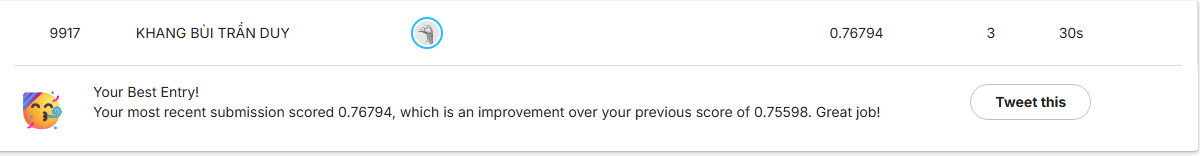